## Useful Visualizations

Oracle user loaded: True
Oracle password loaded: True
Connected to Oracle!


/var/folders/sb/wp21_1l15kq0mgvtyzvc97s40000gq/T/ipykernel_15846/410564728.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql_query("""
/var/folders/sb/wp21_1l15kq0mgvtyzvc97s40000gq/T/ipykernel_15846/410564728.py:64: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql_query("""
/var/folders/sb/wp21_1l15kq0mgvtyzvc97s40000gq/T/ipykernel_15846/410564728.py:80: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql_query("""


df1 shape: (796, 3)
df2 shape: (1586, 2)
df3 shape: (768, 5)
df1 columns: ['genre', 'favorability', 'averagerating']
df2 columns: ['favorability', 'averagerating']
df3 columns: ['genre', 'rating', 'rating_group', 'favorability', 'averagerating']


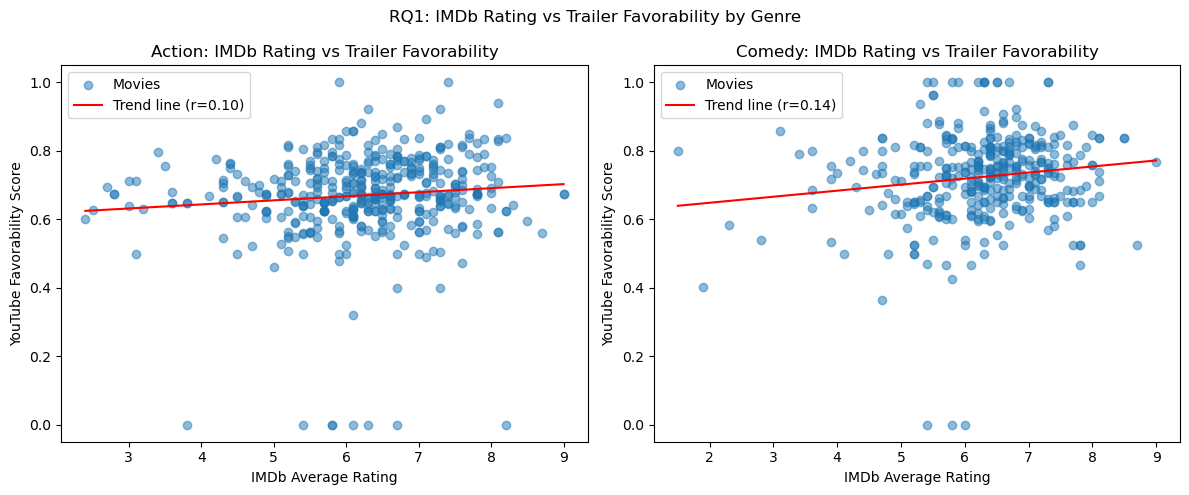

RQ1 plot saved.

RQ1 Interpretation:
The scatter plot shows the correlation between IMDb ratings and YouTube trailer
favorability for Action and Comedy movies. Both genres depict a weak positive trend
(Action movies, r = 0.10; Comedy movies, r = 0.14), indicating that movies with
higher IMDb ratings tend to have more favorable trailers. Comedy movies depict a
slightly stronger correlation compared to Action movies, which may suggest that
audience response to Comedy movies is somewhat more consistent across both platforms.



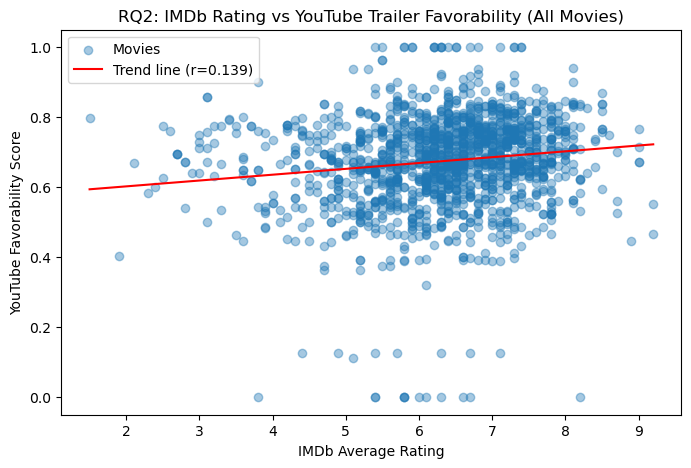

RQ2: r=0.1393, p=0.0000

RQ2 Interpretation:
The scatter plot illustrates the general trend of IMDb ratings and YouTube trailer
favorability for all movies. The linear regression gives an r of 0.139, which is
statistically significant and indicates a weak positive correlation. This suggests that
higher IMDb-rated movies tend to have more favorable trailers, but IMDb rating alone
is not a strong predictor of YouTube trailer favorability.



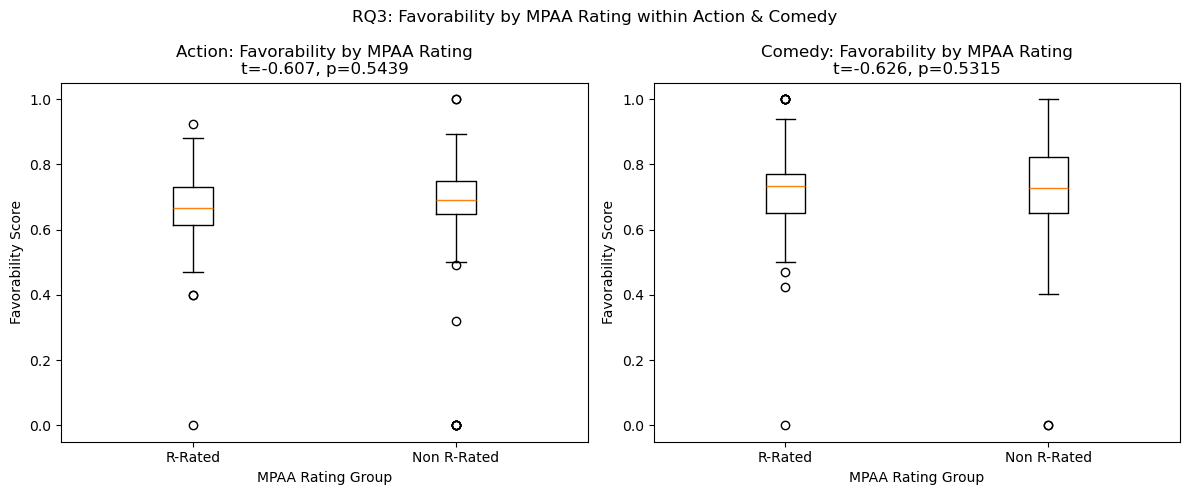

RQ3 plot saved.

RQ3 Interpretation:
The box plots compare the favorability of YouTube trailers for R-Rated and Non-R-Rated
movies within the Action and Comedy genres. In both genres, the difference is not
statistically significant. Therefore, MPAA rating does not appear to meaningfully
impact trailer favorability in this dataset.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import os
import oracledb
from dotenv import load_dotenv

load_dotenv()

# SETUP BEFORE RUNNING:
# 1. Create a .env file in the project root with:
#    ORACLE_USER=ora_CWLID
#    ORACLE_PASSWORD=aSTUDENTNUMBER
# 2. Start SSH tunnel in a separate terminal:
#    ssh -l CWLID -L localhost:1522:dbhost.students.cs.ubc.ca:1522 remote.students.cs.ubc.ca
# 3. Keep the tunnel terminal open while running this notebook
# ============================================================


# STEP 1: CONNECT TO ORACLE

user = os.getenv("ORACLE_USER")
password = os.getenv("ORACLE_PASSWORD")
dsn = "localhost:1522/stu"

print("Oracle user loaded:", user is not None)
print("Oracle password loaded:", password is not None)

if not user or not password:
    raise ValueError("Missing ORACLE_USER or ORACLE_PASSWORD environment variable.")

connection = oracledb.connect(
    user=user,
    password=password,
    dsn=dsn
)

print("Connected to Oracle!")

# STEP 2: FETCH DATA

# Q1
# Fetches genre, favorability, and IMDb rating
# filtered to Action and Comedy movies only
# JOINs all 3 tables using tconst and primaryTitle_norm

df1 = pd.read_sql_query("""
    SELECT 
        ms.genre AS genre,
        ms.favorability AS favorability,
        r.averageRating AS averagerating
    FROM movies m
    JOIN ratings r
        ON m.tconst = r.tconst
    JOIN movie_sentiments ms
        ON m.primaryTitle_norm = ms.name_norm
    WHERE ms.genre IN ('Action', 'Comedy')
""", connection)

# Q2
# Fetches favorability and IMDb rating for ALL movies
# ordered by IMDb rating for linear regression analysis

df2 = pd.read_sql_query("""
    SELECT 
        ms.favorability AS favorability,
        r.averageRating AS averagerating
    FROM movies m
    JOIN ratings r
        ON m.tconst = r.tconst
    JOIN movie_sentiments ms
        ON m.primaryTitle_norm = ms.name_norm
    ORDER BY r.averageRating
""", connection)

# Q3
# Fetches Action and Comedy movies grouped by R vs Non-R
# Excludes 'Not Rated' by filtering to R, PG, PG-13, G only

df3 = pd.read_sql_query("""
    SELECT 
        ms.genre AS genre,
        ms.rating AS rating,
        CASE 
            WHEN ms.rating = 'R' THEN 'R-Rated'
            ELSE 'Non R-Rated'
        END AS rating_group,
        ms.favorability AS favorability,
        r.averageRating AS averagerating
    FROM movies m
    JOIN ratings r
        ON m.tconst = r.tconst
    JOIN movie_sentiments ms
        ON m.primaryTitle_norm = ms.name_norm
    WHERE ms.genre IN ('Action', 'Comedy')
      AND ms.rating IN ('R', 'PG', 'PG-13', 'G')
    ORDER BY ms.genre, rating_group
""", connection)

connection.close()

# Normalize column names to lowercase for consistency
df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()
df3.columns = df3.columns.str.lower()

print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("df3 shape:", df3.shape)
print("df1 columns:", list(df1.columns))
print("df2 columns:", list(df2.columns))
print("df3 columns:", list(df3.columns))

os.makedirs("results", exist_ok=True)

# RQ1 VISUALIZATION
# Two scatter plots side by side: Action and Comedy
# x-axis: IMDb average rating, y-axis: YouTube favorability
# Red trend line shows linear regression for each genre
# r = correlation strength, p = statistical significance

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, genre in zip(axes, ["Action", "Comedy"]):
    subset = df1[df1["genre"] == genre].copy()

    m, b, r_val, p_val, _ = stats.linregress(
        subset["averagerating"],
        subset["favorability"]
    )

    x = np.linspace(
        subset["averagerating"].min(),
        subset["averagerating"].max(),
        100
    )

    ax.scatter(
        subset["averagerating"],
        subset["favorability"],
        alpha=0.5,
        label="Movies"
    )
    ax.plot(
        x,
        m * x + b,
        color="red",
        label=f"Trend line (r={r_val:.2f})"
    )
    ax.set_title(f"{genre}: IMDb Rating vs Trailer Favorability")
    ax.set_xlabel("IMDb Average Rating")
    ax.set_ylabel("YouTube Favorability Score")
    ax.legend()

plt.suptitle("RQ1: IMDb Rating vs Trailer Favorability by Genre")
plt.tight_layout()
plt.savefig("results/rq1_scatter.png")
plt.show()

print("RQ1 plot saved.")
print("""
RQ1 Interpretation:
The scatter plot shows the correlation between IMDb ratings and YouTube trailer
favorability for Action and Comedy movies. Both genres depict a weak positive trend
(Action movies, r = 0.10; Comedy movies, r = 0.14), indicating that movies with
higher IMDb ratings tend to have more favorable trailers. Comedy movies depict a
slightly stronger correlation compared to Action movies, which may suggest that
audience response to Comedy movies is somewhat more consistent across both platforms.
""")

# RQ2 VISUALIZATION
# Single scatter plot for ALL movies
# Linear regression tests if IMDb score predicts favorability
# r value shows overall correlation strength across all genres

m, b, r_val, p_val, _ = stats.linregress(
    df2["averagerating"],
    df2["favorability"]
)

x = np.linspace(
    df2["averagerating"].min(),
    df2["averagerating"].max(),
    100
)

plt.figure(figsize=(8, 5))
plt.scatter(
    df2["averagerating"],
    df2["favorability"],
    alpha=0.4,
    label="Movies"
)
plt.plot(
    x,
    m * x + b,
    color="red",
    label=f"Trend line (r={r_val:.3f})"
)
plt.title("RQ2: IMDb Rating vs YouTube Trailer Favorability (All Movies)")
plt.xlabel("IMDb Average Rating")
plt.ylabel("YouTube Favorability Score")
plt.legend()
plt.savefig("results/rq2_linreg.png")
plt.show()

print(f"RQ2: r={r_val:.4f}, p={p_val:.4f}")
print("""
RQ2 Interpretation:
The scatter plot illustrates the general trend of IMDb ratings and YouTube trailer
favorability for all movies. The linear regression gives an r of 0.139, which is
statistically significant and indicates a weak positive correlation. This suggests that
higher IMDb-rated movies tend to have more favorable trailers, but IMDb rating alone
is not a strong predictor of YouTube trailer favorability.
""")

# RQ3 VISUALIZATION
# Box plots comparing R-Rated vs Non-R-Rated favorability
# Shown separately for Action and Comedy genres

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, genre in zip(axes, ["Action", "Comedy"]):
    subset = df3[df3["genre"] == genre].copy()

    r_group = subset[subset["rating_group"] == "R-Rated"]["favorability"]
    non_r_group = subset[subset["rating_group"] == "Non R-Rated"]["favorability"]

    t_stat, p_val = stats.ttest_ind(
        r_group,
        non_r_group,
        equal_var=False
    )

    ax.boxplot(
        [r_group, non_r_group],
        tick_labels=["R-Rated", "Non R-Rated"]
    )
    ax.set_title(f"{genre}: Favorability by MPAA Rating\nt={t_stat:.3f}, p={p_val:.4f}")
    ax.set_ylabel("Favorability Score")
    ax.set_xlabel("MPAA Rating Group")

plt.suptitle("RQ3: Favorability by MPAA Rating within Action & Comedy")
plt.tight_layout()
plt.savefig("results/rq3_boxplot.png")
plt.show()

print("RQ3 plot saved.")
print("""
RQ3 Interpretation:
The box plots compare the favorability of YouTube trailers for R-Rated and Non-R-Rated
movies within the Action and Comedy genres. In both genres, the difference is not
statistically significant. Therefore, MPAA rating does not appear to meaningfully
impact trailer favorability in this dataset.
""")